# Full Graph

Combine all the individual steps on our Deep Research flow into a single graph

## Imports

In [1]:
import sys 
sys.path.insert(0,"../code")

In [2]:
import utils_display
import prompts
import utils
from utils_import import *
from langchain_core.messages import HumanMessage, SystemMessage
import tools
import rich

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [3]:
from pydantic import BaseModel, Field
from typing import Sequence, Optional, Literal
from langchain_core.messages import BaseMessage

from typing_extensions import Annotated, Sequence
from langchain_core.messages import filter_messages

import operator
from langgraph.types import Command
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, get_buffer_string
from langgraph.graph import StateGraph, START, END


## State

In [4]:

class AgentState(BaseModel):
    """
    State for the research agent scoping workflow.
    """

    # Research brief generated from user conversation history
    research_brief: Optional[str] = None
    # messages exchanged in the conversation
    messages: Annotated[Sequence[BaseMessage], operator.add] = []
    notes:str = ""
    final_report: str = ""


class WorkerAgentState(BaseModel):
    research_brief: Optional[str] = None
    messages: Annotated[Sequence[BaseMessage], operator.add] = []




In [5]:
class ClarifyWithUserOutput(BaseModel):
    """Schema for user clarification decision and questions."""
    
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )


class ResearchQuestionOutput(BaseModel):
    """Schema for structured research brief generation."""
    
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

In [6]:
## Scoping methods

In [7]:
model = ChatOpenAI(
        model="gpt-4.1",
        base_url=OPENAI_BASE_URL,
        temperature=0.0,
        #max_tokens=512,
)

In [8]:
def clarify_with_user(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    Determine if the user's request contains sufficient information to proceed with research, or if a clarifying question is needed.
    """

    
    # Set up structured output model
    structured_output_model = model.with_structured_output(ClarifyWithUserOutput)

    # Invoke the model with clarification instructions
    response = structured_output_model.invoke([
        HumanMessage(content=prompts.clarify_with_user_instructions.format(
            messages=get_buffer_string(messages=state.messages), 
            date=utils.get_today_str()
        ))
    ])
    
    # Route based on clarification need
    if response.need_clarification:
        return Command(
            goto=END, 
            update={"messages": [AIMessage(content=response.question)]}
        )
    else:
        return Command(
            goto="write_research_brief", 
            update={"messages": [AIMessage(content=response.verification)]}
        )

def write_research_brief(state: AgentState):
    """
    Transform the conversation history into a comprehensive research brief.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ResearchQuestionOutput)
    
    # Generate research brief from conversation history
    response = structured_output_model.invoke([
        HumanMessage(content=prompts.transform_messages_into_research_topic.format(
            messages=get_buffer_string(state.messages),
            date=utils.get_today_str()
        ))
    ])
    
    return {
        "research_brief": response.research_brief,
        "messages": [HumanMessage(content=f"{response.research_brief}.")]
    }



def research(state: AgentState):
    llm_tools = [tools.web_search_tool, tools.think_tool, tools.summarize_findings_tool]
    llm = ChatOpenAI(
        model="gpt-4o",
        base_url=OPENAI_BASE_URL,
        temperature=0.7
    )
    system_message = prompts.agent_system_prompt.format(date=utils.get_today_str())
    research_agent = create_agent(
        llm,                          # The LLM to use
        llm_tools,                        # List of tools
        system_prompt=system_message # System prompt
    )


    state_research = WorkerAgentState (research_brief=state.research_brief, messages= [HumanMessage(content= state.research_brief)] )

    state_research = research_agent.invoke(state_research)

    notes = utils.extract_research_notes(state_research['messages'])

    return {"notes": notes , "messages": [AIMessage(content=f"Worker done researching. Notes {notes}")]}



def extract_research_notes(messages:list):
    """
    Extract research notes from the conversation messages.
    Filters messages to include only those generated by tools or the AI.
    """

    raw_notes = [
            str(m.content) for m in filter_messages(
                messages, 
                include_types=["tool", "ai"]
            )
        ]
    return "\n".join(raw_notes)


def final_report_generation(state: AgentState):
    """
    Final report generation node.

    Synthesizes all research findings into a comprehensive final report
    """

    writer_model = ChatOpenAI(
        model="gpt-4.1",
        base_url=OPENAI_BASE_URL,
        max_tokens=32000
    ) 

    # Pull the aggregated research notes captured by previous steps
    notes = extract_research_notes(state.messages)


    final_report_prompt = prompts.final_report_generation.format(
        research_brief=state.research_brief,
        findings=notes,
        date=utils.get_today_str()
    )

    # Use the writer model to generate the final report
    final_report = writer_model.invoke([HumanMessage(content=final_report_prompt)])

    return {
        "final_report": final_report.content, 
         "messages": [AIMessage(content=f" Generated final report. {final_report.content}")]
    }


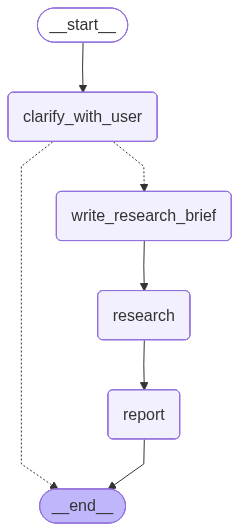

In [9]:
graph_builder = StateGraph(AgentState)

# Add workflow nodes
graph_builder.add_node("clarify_with_user", clarify_with_user)
graph_builder.add_node("write_research_brief", write_research_brief)
graph_builder.add_node("research", research)
graph_builder.add_node("report", final_report_generation)

# add edges
graph_builder.add_edge(START, "clarify_with_user") 
graph_builder.add_edge("write_research_brief", "research") 
graph_builder.add_edge("research", "report") 
graph_builder.add_edge("report", END)


# Compile the full workflow
graph = graph_builder.compile()
graph

In [10]:
query = "What is the best coffee shop in seattle."

In [11]:
result = graph.invoke({"messages": [HumanMessage(content=query)]})


In [12]:
utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere,      │
│ popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [13]:
human_answer = "Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me."
result["messages"] += [HumanMessage(content=human_answer)]
result = graph.invoke(result)



💭 Thinking: To find the best coffee shop in Seattle, we'll need to gather information on several key aspects:

1...
🔍 Searching: best coffee shops in Seattle 2025 quality beans atmosphere
💭 Thinking: From the search results, I have gathered relevant information on the top coffee shops in Seattle foc...
🔍 Searching: Seattle coffee shop reviews 2025 Storyville, Olympia, Starbucks Reserve, Onda Origins
💭 Thinking: The additional search results provide insight into specific coffee shops within Seattle, focusing on...
📝 Summarizing 1798 chars of findings


In [14]:
with tracer.start_as_current_span("full_graph"):
    result = graph.invoke(result)

💭 Thinking: To identify the best coffee shop in Seattle, focusing on the quality of the coffee bean and the atmo...
🔍 Searching: best coffee shops Seattle quality coffee bean atmosphere 2025
💭 Thinking: From the initial search results, I've gathered some valuable insights:

1. **Seattle Coffee Guide 20...
🔍 Searching: customer reviews best Seattle coffee shops 2025 neighborhoods
💭 Thinking: The additional search results have enriched my understanding of Seattle's coffee scene:

1. **Explor...
📝 Summarizing 1930 chars of findings


In [15]:
result

{'research_brief': 'I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean and the atmosphere of the shop, with a focus on establishments within the city of Seattle as a whole. Open considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), and whether other factors such as food offerings or price should be considered.',
 'messages': [HumanMessage(content='What is the best coffee shop in seattle.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere, popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a whole?", additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me.', additional_kwargs={}, response_metadata={

In [16]:
from rich.markdown import Markdown

Markdown(result['final_report'])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                The Best Coffee Shops in Seattle (2025): Spotlight on Coffee Beans and Atmosphere                ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

Seattle’s reputation as a leading American coffee city is well-earned, blending the artistry of specialty coffee   
with an array of distinctive café environments. With a focus on both the quality of coffee beans and the ambiance  
of the shop, the following report reviews the top contenders and contributing factors to Seattle’s enduring coffee 
excellence.                                                                                                        


                                              Criteria for Evaluation                                              

Two core criteria guided the assessment of Seattle’s best coffee shops:                                            

 • Coffee Bean Quality: Emphasis on establishments acclaimed for ethically sourced, flavor-rich beans, with a      
   preference for direct-trade or in-house roasting.                                                               
 • Atmosphere: Environments that elevate the coffee experience, including unique aesthetics, community engagement, 
   and comfortable settings.                                                                                       


                                          Seattle’s Standout Coffee Shops                                          

                                             Storyville Coffee Company                                             

Storyville Coffee Company, located in Pike Place Market, ranks among Seattle’s foremost coffee destinations. The   
shop receives robust customer ratings, including a 4.5/5 average from more than 2,500 reviews. Its atmosphere is   
frequently described as premium and luxurious—characterized by refined decor and “expensive coffee vibes.” As a    
centrally located café popular with locals and visitors alike, Storyville offers a memorable blend of quality beans
and curated ambiance, though with higher pricing that matches the elevated experience ]8;id=827789;https://www.yelp.com/search?find_desc=Coffee+Roasters&find_loc=Seattle%2C+WA\TOP 10 BEST Coffee Roasters ]8;;\ 
]8;id=827789;https://www.yelp.com/search?find_desc=Coffee+Roasters&find_loc=Seattle%2C+WA\in Seattle, WA - Updated 2025 - Yelp]8;;\, ]8;id=628460;https://www.yelp.com/biz/storyville-coffee-company-seattle-9\STORYVILLE COFFEE COMPANY - Updated November 2025 - Yelp]8;;\.                    

                                            Starbucks Reserve Roastery                                             

Distinct from traditional Starbucks locations, the Starbucks Reserve Roastery in Central Seattle provides an       
immersive coffee experience complete with on-site roasting demonstrations and exclusive specialty brews. The       
establishment is recognized for its exceptional service; staff are described as consistently knowledgeable and     
friendly. The space itself serves as a significant tourist draw, with a dramatic, modern interior designed to      
highlight the artistry of coffee, making it more than just a place for a cup—it's a coffee destination in its own  
right ]8;id=2944;https://www.junky-traveler.com/post/seattle-coffee-guide-2025-the-best-cafes-for-work-tourists-instagram-lovers\Seattle Coffee Guide 2025: The Best Cafes for Work, Tourists ...]8;;\, ]8;id=838357;https://www.tripadvisor.com/Attraction_Review-g60878-d7321281-Reviews-or10-Starbucks_Reserve_Roastery_Seattle-Seattle_Washington.html\Starbucks Reserve Roastery Seattle (2025) -]8;;\
]8;id=838357;https://www.tripadvisor.com/Attraction_Review-g60878-d7321281-Reviews-or10-Starbucks_Reserve_Roastery_Seattle-Seattle_Washington.html\Tripadvisor]8;;\.    

In [17]:
utils_display.format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ What is the best coffee shop in seattle.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste, atmosphere,      │
│ popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the city as a  │
│ whole?                                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Quality of the coffee bean and the atmosphere of the shop are the two most important factors for me.            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying your priorities: quality of the coffee bean and the atmosphere of the shop. I have     │
│ enough information to begin researching the best coffee shops in Seattle based on these criteria.               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean and the           │
│ atmosphere of the shop. The focus should be on establishments within the city of Seattle as a whole. Open       │
│ considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), │
│ and whether other factors such as food offerings or price should be considered..                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│  Generated final report. # The Best Coffee Shops in Seattle (2025): Focus on Coffee Bean Quality and Atmosphere │
│                                                                                                                 │
│ Seattle, renowned for its rich coffee culture and as the birthplace of several coffee innovations, boasts a     │
│ diverse selection of coffee shops ranging from cozy local spots to immersive retail experiences. This report    │
│ identifies leading coffee shops within the city by prioritizing the quality of their coffee beans and the       │
│ atmosphere of their establishments. The evaluation draws on multiple recent guides and reviews, ensuring        │
│ balanced coverage across firsthand experiences and expert curation.                                             │
│                                                                                                                 │
│ ## Criteria for Selection                                                                                       │
│                                                                                                                 │
│ Two primary criteria informed this assessment:                                                                  │
│ - **Quality of Coffee Beans:** Shops and roasters known for exceptional sourcing, flavor, and ethical           │
│ practices.                                                                                                      │
│ - **Atmosphere:** Environments that enhance the coffee experience, whether through design, ambiance, or         │
│ service.                                                                                                        │
│                                                                                                                 │
│ ## Top Contenders: Seattle’s Exemplary Coffee Shops                                                             │
│                                                                                                                 │
│ ### Storyville Coffee Company                                                                                   │
│                                                                                                                 │
│ Located in Pike Place Market, Storyville Coffee Company consistently ranks among Seattle's finest coffee        │
│ destinations. It garners a notable 4.5/5 rating from over 2,500 reviewers, signaling both enduring popularity   │
│ and high customer satisfaction. The shop is described as providing "expensive coffee vibes," reflecting not     │
│ only premium pricing but also a luxurious ambiance and attention to detail in its offerings. The central        │
│ location makes it a popular stop for tourists wishing to experience Seattle's coffee tradition in a bustling,   │
│ historic setting. While prices may be higher relative to some competitors, the ambiance and quality are         │
│ considered commensurate by many patrons [TOP 10 BEST Coffee Roasters in Seattle, WA - Updated 2025 -            │
│ Yelp](https://www.yelp.com/search?find_desc=Coffee+Roasters&find_loc=Seattle%2C+WA), [STORYVILLE COFFEE COMPANY │
│ - Updated November 2025 - Yelp](https://www.yelp.com/biz/storyville-coffee-company-seattle-9).                  │
│                                                                                                                 │
│ ### Starbucks Reserve Roastery                                                                                  │
│                                                                                                                 │
│ Central Seattle is home to the flagship Starbucks Reserve Roastery, which offers an immersive, upscale coffee   │
│ experience beyond the standard café format. It stands o

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ You have provided sufficient information: the goal is to identify the best coffee shop in Seattle, prioritizing │
│ coffee bean quality and shop atmosphere, with a city-wide focus. No further clarification is needed. Proceeding │
│ with research and reporting based on these criteria.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean and the           │
│ atmosphere of the shop, with a focus on establishments within the city of Seattle as a whole. Open              │
│ considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), │
│ and whether other factors such as food offerings or price should be considered..                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Worker done researching. Notes                                                                                  │
│ Reasoning recorded: To identify the best coffee shop in Seattle, focusing on the quality of the coffee bean and │
│ the atmosphere, I should consider the following aspects:                                                        │
│                                                                                                                 │
│ 1. **Quality of Coffee Bean**: Research which coffee shops are known for sourcing high-quality beans, perhaps   │
│ those that roast their own beans or have unique partnerships with renowned coffee suppliers.                    │
│                                                                                                                 │
│ 2. **Atmosphere**: Determine which shops are noted for their atmosphere, whether it's cozy, modern, or lively.  │
│ I should look for customer reviews or local guides that highlight these aspects.                                │
│                                                                                                                 │
│ 3. **Location**: Since the user is open to specific neighborhoods, I should identify coffee shops in various    │
│ popular areas of Seattle, such as Capitol Hill, Ballard, or Downtown.                                           │
│                                                                                                                 │
│ 4. **Additional Considerations**: While the focus is on coffee and atmosphere, I should also note if any shops  │
│ are praised for their food offerings or affordability, as these can be secondary benefits.                      │
│                                                                                                                 │
│ To gather this information, I will conduct a series of web searches:                                            │
│ - First, to find lists or articles that rank coffee shops in Seattle based on coffee quality and atmosphere.    │
│ - Then, to look for customer reviews or forums where people discuss their favorite coffee shops in Seattle,     │
│ focusing on the mentioned criteria.                                                                             │
│ - Finally, to identify any standout shops in specific neighborhoods that are frequently mentioned or highly     │
│ rated.                                                                                                          │
│                                                                                                                 │
│ Search results for: 'best coffee shops Seattle quality coffee bean atmosphere 2025'                             │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Seattle Coffee Guide 2025: The Best Cafes for Work, Tourists ... ---                              │
│ URL:                                                                                                            │
│ https://www.junky-traveler.com/post/seattle-coffee-guide-2025-the-best-cafes-for-work-tourists-instagram-lovers │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ The Seattle Coffee Guide offers a curated list of the best local cafés ideal for work and Instagram photography │
│ in Seattle, known for its vibrant coffee culture. Featured cafés include Olympia Coffee, Zeitgeist Coffee, and  │
│ URL Coffee, each noted for their welcoming atmospheres 

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│  Generated final report. # The Best Coffee Shops in Seattle (2025): Spotlight on Coffee Beans and Atmosphere    │
│                                                                                                                 │
│ Seattle’s reputation as a leading American coffee city is well-earned, blending the artistry of specialty       │
│ coffee with an array of distinctive café environments. With a focus on both the quality of coffee beans and the │
│ ambiance of the shop, the following report reviews the top contenders and contributing factors to Seattle’s     │
│ enduring coffee excellence.                                                                                     │
│                                                                                                                 │
│ ## Criteria for Evaluation                                                                                      │
│                                                                                                                 │
│ Two core criteria guided the assessment of Seattle’s best coffee shops:                                         │
│                                                                                                                 │
│ - **Coffee Bean Quality:** Emphasis on establishments acclaimed for ethically sourced, flavor-rich beans, with  │
│ a preference for direct-trade or in-house roasting.                                                             │
│ - **Atmosphere:** Environments that elevate the coffee experience, including unique aesthetics, community       │
│ engagement, and comfortable settings.                                                                           │
│                                                                                                                 │
│ ## Seattle’s Standout Coffee Shops                                                                              │
│                                                                                                                 │
│ ### Storyville Coffee Company                                                                                   │
│                                                                                                                 │
│ Storyville Coffee Company, located in Pike Place Market, ranks among Seattle’s foremost coffee destinations.    │
│ The shop receives robust customer ratings, including a 4.5/5 average from more than 2,500 reviews. Its          │
│ atmosphere is frequently described as premium and luxurious—characterized by refined decor and “expensive       │
│ coffee vibes.” As a centrally located café popular with locals and visitors alike, Storyville offers a          │
│ memorable blend of quality beans and curated ambiance, though with higher pricing that matches the elevated     │
│ experience [TOP 10 BEST Coffee Roasters in Seattle, WA - Updated 2025 -                                         │
│ Yelp](https://www.yelp.com/search?find_desc=Coffee+Roasters&find_loc=Seattle%2C+WA), [STORYVILLE COFFEE COMPANY │
│ - Updated November 2025 - Yelp](https://www.yelp.com/biz/storyville-coffee-company-seattle-9).                  │
│                                                                                                                 │
│ ### Starbucks Reserve Roastery                                                                                  │
│                                                                                                                 │
│ Distinct from traditional Starbucks locations, the Starbucks Reserve Roastery in Central Seattle provides an    │
│ immersive coffee experience complete with on-site roasting demonstrations and exclusive specialty brews. The    │
│ establishment is recognized for its exceptional service

In [18]:
rich.print (result)

{
    'research_brief': 'I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee 
bean and the atmosphere of the shop, with a focus on establishments within the city of Seattle as a whole. Open 
considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), and
whether other factors such as food offerings or price should be considered.',
    'messages': [
        HumanMessage(
            content='What is the best coffee shop in seattle.',
            additional_kwargs={},
            response_metadata={}
        ),
        AIMessage(
            content="Could you clarify what you mean by 'best'? Are you looking for the best coffee based on taste,
atmosphere, popularity, or something else? Also, are you interested in a specific neighborhood in Seattle or the 
city as a whole?",
            additional_kwargs={},
            response_metadata={}
        ),
        HumanMessage(
            content='Quality of the coffee bean and the atmosphere of the shop are the two most important factors 
for me.',
            additional_kwargs={},
            response_metadata={}
        ),
        AIMessage(
            content='Thank you for clarifying your priorities: quality of the coffee bean and the atmosphere of the
shop. I have enough information to begin researching the best coffee shops in Seattle based on these criteria.',
            additional_kwargs={},
            response_metadata={}
        ),
        HumanMessage(
            content='I am researching the best coffee shop in Seattle, prioritizing the quality of the coffee bean 
and the atmosphere of the shop. The focus should be on establishments within the city of Seattle as a whole. Open 
considerations: specific neighborhoods of interest, preferred style of atmosphere (e.g., cozy, modern, lively), and
whether other factors such as food offerings or price should be considered..',
            additional_kwargs={},
            response_metadata={}
        ),
        AIMessage(
            content='Worker done researching. Notes \nReasoning recorded: To find the best coffee shop in Seattle, 
we\'ll need to gather information on several key aspects:\n\n1. **Quality of Coffee Bean:**\n   - Which coffee 
shops are known for their high-quality coffee beans?\n   - Are there specific brands or sources of beans that are 
particularly noteworthy?\n\n2. **Atmosphere of the Shop:**\n   - What types of atmospheres do Seattle\'s coffee 
shops offer (e.g., cozy, modern, lively)?\n   - How do these atmospheres enhance the coffee-drinking 
experience?\n\n3. **Specific Neighborhoods:**\n   - Are there neighborhoods in Seattle known for having a high 
concentration of excellent coffee shops?\n   - How do these neighborhoods compare in terms of coffee culture?\n\n4.
**Additional Considerations:**\n   - Should we consider food offerings, price, or other factors like customer 
service or sustainability?\n\nGiven these aspects, I will start by searching for lists or articles that rank or 
discuss the best coffee shops in Seattle, focusing on coffee quality and atmosphere. I\'ll also look for any 
notable reviews or guides that emphasize these criteria. I\'ll aim to identify a few top contenders and explore 
what makes them stand out in more detail.\n\nSearch results for: \'best coffee shops in Seattle 2025 quality beans 
atmosphere\'\n\n\n--- SOURCE 1: Seattle Coffee Guide 2025: The Best Cafes for Work, Tourists ... ---\nURL: 
https://www.junky-traveler.com/post/seattle-coffee-guide-2025-the-best-cafes-for-work-tourists-instagram-lovers\n\n
<summary>\nThe webpage features a comprehensive guide to the best coffee shops in Seattle, ideal for work and 
social media photography. Highlighting the city\'s rich coffee culture, it showcases local spots known for their 
unique ambiance and high-quality brews. The guide includes details on hours of operation and the overall vibe of 
various cafes such as Olympica Coffee, Zei